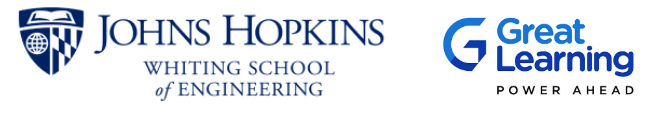

<font size=10>**End-Term / Final Project**</font>

<font size=6>**AI for Research Proposal Automation**</font>


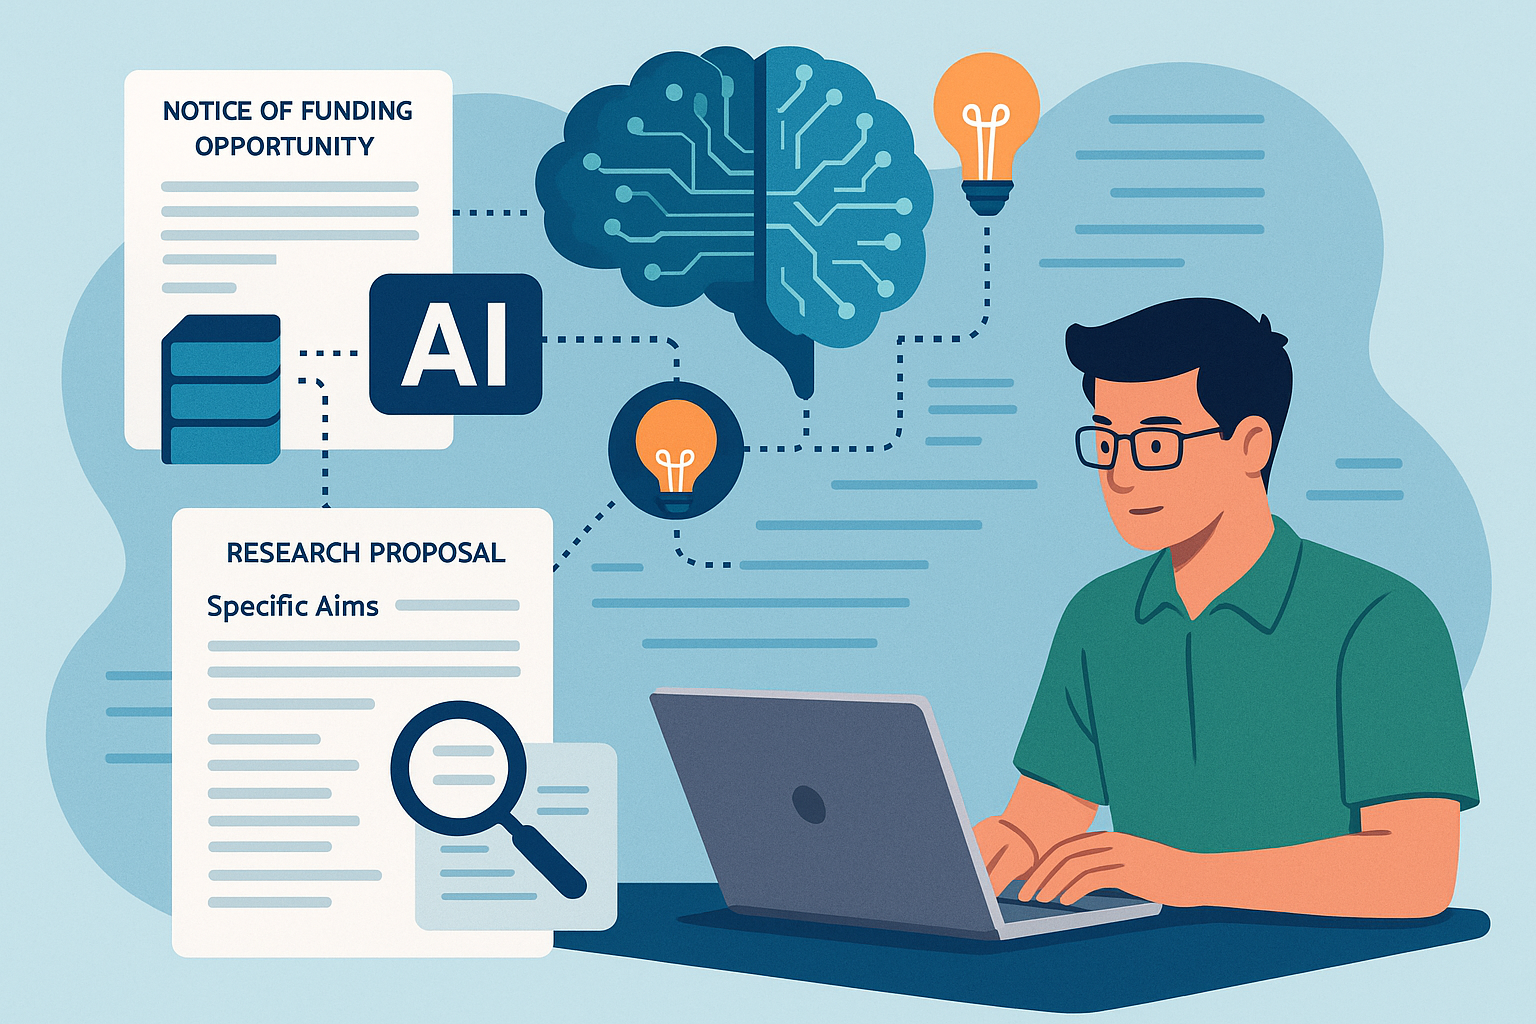

### **Business Problem - Create an AI system which will help you writing the research proposal aligning with the NOFO Document**
   



Meet Dr. Ian McCulloh, a seasoned research advisor and a leading voice in interdisciplinary science. Over the years, his lab has explored everything from AI for counterterrorism to social network analysis in neuroscience. His publication portfolio is vast, rich, and... chaotic.

When the National Institute of Mental Health released a new NOFO (Notice of Funding Opportunity) seeking innovative digital health solutions for mental health equity, Dr. Ian saw an opportunity. But there was a problem: despite his extensive work, none of his existing research was directly aligned with digital mental health interventions. And with NIH deadlines looming, manually identifying relevant angles and generating a competitive proposal would be a massive lift.

Dr. Ian wished for a smart assistant—one that could digest his past work, interpret the NOFO’s intent, spark new research directions, and even help draft proposal sections.

**The Challenge:**

Organizations and researchers often maintain large archives of publications and prior work. When responding to competitive grants—especially highly specific ones like NIH NOFOs—it becomes extremely difficult and time-consuming to:

1. Align past work with a new funding call.
2. Extract relevant expertise from unrelated projects.
3. Ideate novel, fundable research proposals tailored to complex criteria.
4. Generate high-quality text for grant submission that satisfies technical and scientific review criteria.

The manual effort to sift through dense research documents, match them to nuanced funding criteria, and write compelling, compliant proposals is labor-intensive, inconsistent, and prone to missed opportunities.

### **The Case Study Approach**

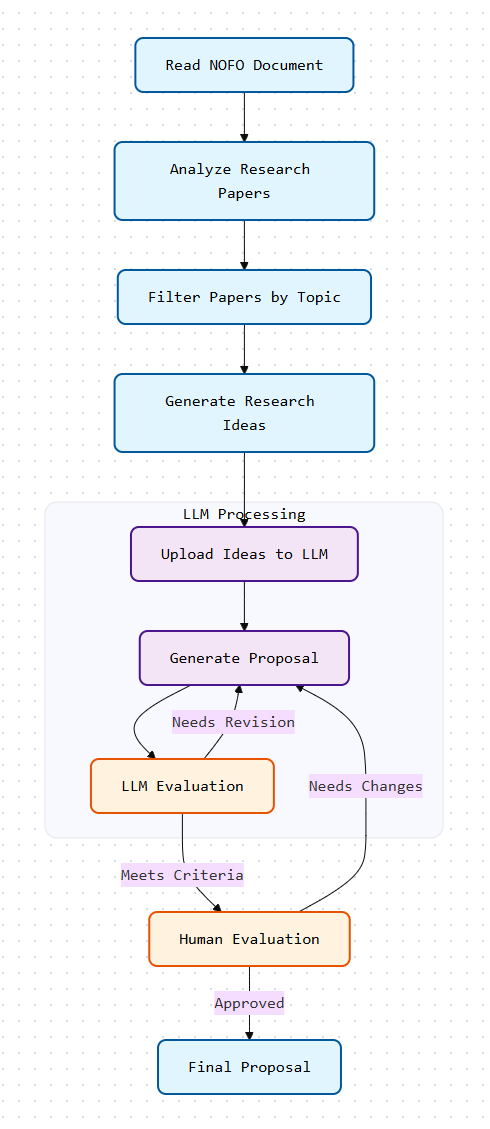

**Objective**
1. Develop a generative AI-powered system using LLMs to automate and optimize the creation of NIH research proposals.
2. The tool will identify relevant prior research, generate aligned project ideas, and draft high-quality proposal content tailored to specific NOFO requirements.

## **Setup - [3 Marks]**
---
<font color=Red>**Note:**</font> *2 marks for Loading the Config file details and 1 mark for the LLM Configuration.*

There have been recent updates in Google colab workspace. Please ignore the errors and warnings that may arise for the library installations.

**How bulk installs fail !!**

- When you run pip install with multiple packages and version constraints, pip's dependency resolver attempts to find a single, consistent set of package versions that satisfies all of the specified requirements.

*Earlier code syntax:*
```
!pip install -q langchain==0.3.21 \
                huggingface_hub==0.29.3 \
                openai==1.68.2 \
                chromadb==0.6.3 \
                langchain-community==0.3.20 \
                langchain_openai==0.3.10 \
                lark==1.2.2\
                rank_bm25==0.2.2\
                numpy==2.2.4 \
                scipy==1.15.2 \
                scikit-learn==1.6.1 \
                transformers==4.50.0 \
                pypdf==5.4.0 \
                markdown-pdf==1.7 \
                tiktoken==0.9.0 \
                sentence_transformers==4.0.0 \
                torch==2.6.0+cu124
```

Let's say you provide a list of packages: `A==1.0`, `B==2.0`, `C==3.0`.
* Package A might require `helper>=1.1`.
* Package B might require `helper<=1.0`.

In a single command, pip sees that packages A and B have conflicting requirements for helper. It won't install a version of helper that breaks either package, so it will report an error and stop the entire installation.

In [ ]:
# @title Run these cells => Restart the session (only if asked) => Start executing the below cells **(DO NOT EXECUTE THESE CELLS AGAIN)**

!pip install -q langchain==0.3.21 \
                huggingface_hub==0.29.3 \
                openai==1.68.2

# You may see an error message which can be ignored

In [ ]:
! pip install -q chromadb==0.6.3

In [ ]:
!pip install -q langchain-community==0.3.20 \
                langchain_openai==0.3.10

In [ ]:
!pip install -q lark==1.2.2\
                rank_bm25==0.2.2

# You may see an error message which can be ignored

In [ ]:
!pip install -q numpy==2.2.4 \
                scipy==1.15.2 \
                scikit-learn==1.6.1

# You may see an error message which can be ignored

In [ ]:
!pip install -q transformers==4.50.0 \
                pypdf==5.4.0 \
                markdown-pdf==1.7 \
                tiktoken==0.9.0 \
                sentence_transformers==4.0.0

In [ ]:
!pip install -q torch==2.6.0 --index-url https://download.pytorch.org/whl/cu124

# This will take some time to install
# You may see an error message which can be ignored

**How individual installs succeed**

When you install packages one by one, the dependency resolution process is simpler for each step. The state of the environment changes with each successful installation, which can accidentally resolve conflicts.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# @title Loading the `config.json` file
import json
import os

# Load the JSON file and extract values
file_name = 'config.json'
with open(file_name, 'r') as file:
    config = json.load(file)
    os.environ['OPENAI_API_KEY'] = config.get("") # Loading the API Key
    os.environ["OPENAI_BASE_URL"] = config.get("") # Loading the API Base Url

In [ ]:
# @title Defining the LLM Model - Use `gpt-4o-mini` Model
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="", temperature=0)

## **Step 1: Topic Extraction - [6 Marks]**

> **Read the NOFO doc and identify the topic for which the funding is to be given.**
---
<font color=Red>**Note:**</font> *4 marks are awarded for the prompt and 2 marks for the successful completion of this section, including debugging or modifying the code if necessary.*
   

In [ ]:
from langchain.document_loaders import PyPDFLoader

# Reading the NOFO Document
pdf_file = ""
pdf_loader = PyPDFLoader(pdf_file);
NOFO_pdf = pdf_loader.load()

**TASK:** Write an LLM prompt to extract the Topic for what the funding is been provided, from the NOFO document, Ask the LLM to respond back with the topic name only and nothing else.

In [ ]:
topic_extraction_Prompt = f"""

<WRITE YOUR PROMPT HERE>

"""

In [ ]:
# Finding the topic for which the Funding is been given
topic_extraction = llm.invoke(topic_extraction_Prompt)
topic = topic_extraction.content
topic

'Digital Mental Health Interventions'

## **Step 2: Research Paper Relevance Assessment - [7 Marks]**
> **Analyze all the Research Papers and filter out the research papers based on the topic of NOFO**
---
<font color=Red>**Note:**</font> *4 marks are awarded for the prompt and 2 marks for the successful completion of this section, including debugging or modifying the code if necessary. 1 mark for output generation.*

**TASK:** Write an Prompt which can be used to analyze the relevance of the provided research paper in relation to the topic outlined in the NOFO (Notice of Funding Opportunity) document. Determine whether the research aligns with the goals, objectives, and funding criteria specified in the NOFO. Additionally, assess whether the research paper can be used to support or develop a viable project idea that fits within the scope of the funding opportunity.

<br>

**Note:** If the paper does **not** significantly relate to the topic—by domain, method, theory, or application ask the LLM to return: **"PAPER NOT RELATED TO TOPIC"**


<br>

Ask the LLM to respond in the below specified structure:

```
### Output Format:
"summary": "<summary of the paper under 300 words, or return: PAPER NOT RELATED TO TOPIC>"

```

In [ ]:
# Unzipping the Research Papers - Replace your zip file path and extarct it in the contents folder only
import zipfile
with zipfile.ZipFile(" <YOUR ZIP FILE PATH OF RESEARCH PAPERS> ", 'r') as zip_ref:
  zip_ref.extractall("/content/") # No changes needed here

In [ ]:
relevance_prompt = f"""


<WRITE YOUR PROMPT HERE>




### Research Paper Context:
"""


In [ ]:
import tiktoken

# Reading all PDF files and storing it in 1 variable
path = "/content/Papers/"
documents = []
total_files  = len(os.listdir(path))

# Defining the max tokens to avoid error for context being to long
encoding = tiktoken.encoding_for_model("gpt-4o-mini")
MAX_TOKENS = 127500

progress_cnt = 1
relevant_papers_count = 0
irrelevant_papers_count = 0

for filename in os.listdir(path):
    if filename.endswith('.pdf'):
        file_path = os.path.join(path, filename)

        try:
            # Load PDF
            docs = PyPDFLoader(file_path,mode="single").load()
            # extracting the pages
            pages = docs[0].page_content

            # combining the prompt with the pages of the research paper within the context length
            available_tokens = MAX_TOKENS - len(encoding.encode(relevance_prompt ))
            truncated_pages = encoding.decode(encoding.encode(pages)[:available_tokens])
            full_prompt = relevance_prompt + truncated_pages

            # Calling the LLM
            response = llm.invoke(full_prompt)

            print(f"Successfully processed: {progress_cnt}/{total_files}")
            progress_cnt += 1

            #  If the paper is not relevant skipping the paper
            if  "PAPER NOT RELATED TO TOPIC" in response.content:
              irrelevant_papers_count += 1
              continue

            #  If the paper is relevant adding it to the documents variable
            documents.append({ 'title': filename, 'llm_response': response.content, 'file_path':file_path})
            relevant_papers_count += 1

        except Exception as e:
            print(f"!!! Error processing {filename}: {str(e)}")


print("="*50)
print(f"Relevant Papers: {relevant_papers_count}/{total_files}")
print(f"Irrelevant Papers: {irrelevant_papers_count}/{total_files}")



Successfully processed: 1/112


Successfully processed: 2/112


Successfully processed: 3/112
Successfully processed: 4/112
Successfully processed: 5/112
Successfully processed: 6/112
Successfully processed: 7/112


Successfully processed: 8/112


Successfully processed: 9/112
Successfully processed: 10/112
Successfully processed: 11/112
Successfully processed: 12/112
Successfully processed: 13/112


...

Successfully processed: 64/112
Successfully processed: 65/112
Successfully processed: 66/112
Successfully processed: 67/112
Successfully processed: 68/112
Successfully processed: 69/112
Successfully processed: 70/112
Successfully processed: 71/112
Successfully processed: 72/112
Successfully processed: 73/112
Successfully processed: 74/112
Successfully processed: 75/112
Successfully processed: 76/112
Successfully processed: 77/112
Successfully processed: 78/112
Successfully processed: 79/112
Successfully processed: 80/112
Successfully processed: 81/112
Successfully processed: 82/112
Successfully processed: 83/112
Successfully processed: 84/112
Successfully processed: 85/112


Successfully processed: 86/112
Successfully processed: 87/112
Successfully processed: 88/112
Successfully processed: 89/112
Successfully processed: 90/112


Successfully processed: 91/112
Successfully processed: 92/112
Successfully processed: 93/112
Successfully processed: 94/112
Successfully processed: 95/112
Successfully processed: 96/112
Successfully processed: 97/112
Successfully processed: 98/112
Successfully processed: 99/112


Successfully processed: 100/112
Successfully processed: 101/112


Successfully processed: 102/112
Successfully processed: 103/112
Successfully processed: 104/112
Successfully processed: 105/112
Successfully processed: 106/112
Successfully processed: 107/112
Successfully processed: 108/112
Successfully processed: 109/112
Successfully processed: 110/112
Successfully processed: 111/112
Successfully processed: 112/112
Relevant Papers: 22/112
Irrelevant Papers: 90/112


In [ ]:
documents

[{'title': 'Social Media Mental Health Final.pdf',
  'llm_response': '"summary": "The paper titled \\"Fragile Minds: Exploring the Link Between Social Media and Young Adult Mental Health\\" investigates the relationship between social media usage and mental health outcomes among college students, a demographic particularly affected by the mental health crisis exacerbated by social media. The authors conducted a survey of 254 undergraduate students to assess correlations between social media use, fear of missing out (FoMO), loneliness, and personality traits. Their findings indicate a moderate correlation between social media use and FoMO, as well as a weak inverse correlation between loneliness and the use of platforms like Instagram and Snapchat. Notably, the study suggests that the shift from text-based to video-based social media may be altering the impact of social media on mental health, potentially reducing risks associated with its use.\n\nThe core contributions of this paper in

## **Step 3: Proposal Ideation Based on Filtered Research - [9 marks]**
> **Use the filtered papers, to generate ideas for the Reseach Proposal.**
---
<font color=Red>**Note:**</font> *4 marks are awarded for the prompt, 2 marks for the Generating Idea, 1 mark for citations and 1 mark for fetching the file path of the chosen idea, along with successful completion of this section, including debugging or modifying the code if necessary. 1 mark for the output generated.*

**TASK:** Write an Prompt which can be used to generate 5 ideas for the Research Proposal, each idea should consist:

1. **Idea X:** [Concise Title of the Project Idea]  \n
2. **Description:** [Brief and targeted description summarizing the objectives, innovative elements, scientific rationale, and anticipated impact.]  \n
3. **Citation:** [Author(s), Year or Paper Title]  \n
4. **NOFO Alignment:** [List two or more specific NOFO requirements that this idea directly addresses]  \n
5. **File Path of the Research Paper:** [Exact file path, ending in .pdf]

- Use the Delimiter `---` for defining the structure of the sample outputs in the prompt





#### Generating 5 Ideas

In [ ]:
gen_idea_prompt = f"""


<WRITE YOUR PROMPT HERE>


"""

In [ ]:
ideas = llm.invoke(gen_idea_prompt)

In [ ]:
from IPython.display import Markdown, display
display(Markdown(ideas.content))

---
**Idea 1:** Enhancing Mental Health Engagement through Adaptive Social Media Interventions  

**Description:** This project proposes the development of a digital mental health intervention that leverages social media dynamics to deliver personalized, adaptive content based on user engagement patterns and emotional responses, utilizing insights from the relationship between social media use and mental health outcomes (Cruickshank & Carley, 2021). By integrating real-time data collection and feedback mechanisms, the intervention aims to improve user adherence and reduce symptoms of anxiety and depression, particularly among young adults.  

**Citation:** Cruickshank, J., & Carley, K. (2021). Characterizing Communities of Hashtag Usage on Twitter During the 2020 COVID-19 Pandemic.  

**NOFO Alignment:** 1) Test strategies to deliver digital mental health interventions designed to overcome uptake and adherence challenges; 2) Utilize real-time data collection and feedback to enhance intervention effectiveness.  

**File Path of the Research Paper:** /content/Papers/Characterizing_Communities_of_Hashtag_Usage_on_Twitter_During_the_2020_COVID_19_Pandemic.pdf  

---
**Idea 2:** Neurofeedback-Driven Digital Interventions for Substance Use Disorders  

**Description:** This project aims to develop a digital platform that utilizes eye-tracking and facial expression recognition technologies to provide neurofeedback interventions for individuals with substance use disorders, enhancing engagement through personalized feedback based on physiological responses (Arrow White Paper DExTra, 2021). The intervention will be designed to improve treatment adherence and reduce relapse rates by providing real-time insights into emotional and cognitive states during recovery.  

**Citation:** Arrow White Paper DExTra (2021).  

**NOFO Alignment:** 1) Develop and test adaptive interventions that can be ‘pushed out’ via mobile technology based on real-time user data; 2) Focus on treating serious mental illness and substance use disorders.  

**File Path of the Research Paper:** /content/Papers/Arrow White Paper DExTra.pdf  

---
**Idea 3:** AI-Enhanced Misinformation Countermeasures in Mental Health  

**Description:** This project proposes a digital intervention that employs agent-based simulations to tailor counter-disinformation strategies for mental health messaging, addressing cognitive biases that affect public perceptions of mental health issues (Lospinoso, McCulloh, & Carley, 2021). By utilizing large language models to simulate user responses, the intervention aims to enhance the effectiveness of mental health campaigns and reduce stigma associated with seeking help.  

**Citation:** Lospinoso, J., McCulloh, I., & Carley, K. (2021). Utility Seeking in Complex Social Systems.  

**NOFO Alignment:** 1) Test digital health technology-driven approaches to improve access and promote engagement with mental health services; 2) Address known challenges with uptake and adherence to technology-based approaches.  

**File Path of the Research Paper:** /content/Papers/Utility Seeking in Complex Social Systems.pdf  

---
**Idea 4:** Personalized Mental Health Interventions Using Neural Data  

**Description:** This project aims to create a digital mental health intervention that utilizes functional near-infrared spectroscopy (fNIRS) to assess neural responses to therapeutic content, allowing for personalized adjustments based on individual emotional and cognitive profiles (Dieffenbach et al., 2021). The intervention seeks to enhance treatment efficacy for serious mental illnesses by tailoring content delivery to optimize user engagement and therapeutic outcomes.  

**Citation:** Dieffenbach, K., et al. (2021). NeuroSynchrony.  

**NOFO Alignment:** 1) Develop and test strategies to optimize digital health interventions based on user engagement and neural responses; 2) Focus on treating serious mental illness through innovative technology.  

**File Path of the Research Paper:** /content/Papers/NeuroSynchrony.pdf  

---
**Idea 5:** Social Network Analysis for Suicide Prevention Messaging  

**Description:** This project proposes a digital intervention that employs social network analysis (SNA) to identify key influencers and information pathways in online communities, enhancing the dissemination of suicide prevention messages tailored to specific demographic groups (McCulloh et al., 2012). By leveraging insights from network dynamics, the intervention aims to improve the reach and impact of mental health campaigns, particularly among vulnerable populations.  

**Citation:** McCulloh, I., Johnson, J., & Carley, K. (2012). Spectral Analysis SNA.  

**NOFO Alignment:** 1) Test strategies to rapidly identify and enroll participants in mental health interventions; 2) Utilize digital health interventions that address health disparities in access and service utilization.  

**File Path of the Research Paper:** /content/Papers/Spectral Analysis SNA.pdf  

#### Choosing 1 Idea and fetching details

In [ ]:
# Modify the idea_number for choosing the different idea
idea_number = 5   # change the number if you wish to choose and generate the research proposal for another idea
chosen_idea = ideas.content.split("---")[idea_number]

In [ ]:
import re

# Use a regular expression to find the file path of the research paper

pattern = r"File Path of the Research Paper:\*\*\s*(.+?)\n"
# If you are unable to extract the file path successfully using this pattern, use the `ChatGPT` or any other LLM to find the pattern that works for you, simply provide the LLM the sample response of your whole ideas and ask the LLM to generate the regex patterm for extracting the "File Path of the Research Paper"

match = re.search(pattern, chosen_idea)

if match:
  idea_generated_from_research_paper = match.group(1).strip()
  print("Filepath : ", idea_generated_from_research_paper)
else:
  print("File Path of the Research Paper not found in the chosen idea.")

Filepath : /content/Papers/Spectral Analysis SNA.pdf


## **Step 4: Proposal Blueprint Preparation - [6 Marks]**

> **Select appropriate research ideas for the proposal and supply 'Sample Research Proposals' as templates to the LLM to support the generation of the final proposal.**
---   
<font color=Red>**Note:**</font> *4 marks are awarded for the prompt and 2 marks for the successful completion of this section, including debugging or modifying the code if necessary.*

**TASK:** Write an Prompt which can be used to generate the Research Proposal.

The prompt should be able to craft a research proposal based on the sample research proposal template, using one of the ideas generated above. The proposal should include references to the actual research papers from which the ideas are derived and should align well with the NOFO documents.

In [ ]:
# Here we need to add the full papers instead of the summary
chosen_idea_rp = PyPDFLoader(idea_generated_from_research_paper, mode="single").load()

# Loading the sample research proposal template
research_proposal_template = PyPDFLoader(" <Path of Research Proposal Template> ", mode="single").load()

In [ ]:
research_proposal_template_prompt = f"""


<WRITE YOUR PROMPT HERE>


"""

In [ ]:
research_plan = llm.invoke(research_proposal_template_prompt)

In [ ]:
display(Markdown(research_plan.content))

# Research Proposal: Social Network Analysis for Suicide Prevention Messaging

## 1. Introduction
Suicide remains a significant public health concern, with over 700,000 individuals dying by suicide each year globally (World Health Organization, 2021). The need for effective suicide prevention strategies is critical, particularly among vulnerable populations who often face barriers to accessing mental health services. This proposal outlines a research project that leverages Social Network Analysis (SNA) to enhance the dissemination of suicide prevention messages tailored to specific demographic groups. By identifying key influencers and information pathways within online communities, this project aims to improve the reach and impact of mental health campaigns, ultimately reducing suicide rates.

## 2. Problem Statement
Despite the increasing prevalence of digital health interventions, many individuals, particularly those from marginalized communities, remain disconnected from mental health resources. Current suicide prevention strategies often fail to engage these populations effectively. The lack of targeted messaging and the inability to identify influential community members hinder the dissemination of critical information. This project seeks to address the following research questions:
1. How can SNA be utilized to identify key influencers within online communities for suicide prevention messaging?
2. What are the most effective pathways for disseminating tailored suicide prevention messages to vulnerable populations?
3. How can the impact of these tailored messages on suicide prevention be measured?

## 3. Objectives
The long-term goal of this research is to develop a scalable digital intervention that utilizes SNA to optimize suicide prevention messaging. The specific objectives of this study are:
1. To identify key influencers within online communities who can effectively disseminate suicide prevention messages.
2. To develop tailored messaging strategies based on demographic and psychographic data of target populations.
3. To evaluate the effectiveness of these tailored messages in increasing engagement and reducing suicidal ideation among participants.

## 4. Preliminary Literature Review
Previous research has demonstrated the efficacy of digital health interventions in improving mental health outcomes (McCulloh et al., 2012). However, there is a notable gap in the literature regarding the application of SNA in suicide prevention. Studies have shown that individuals are more likely to engage with health messages when they come from trusted sources within their social networks (Valente, 2010). Furthermore, the use of tailored messaging has been linked to increased effectiveness in health communication (Kreuter et al., 2000). This project builds on these findings by integrating SNA with tailored messaging strategies to enhance the impact of suicide prevention efforts.

## 5. Methodology
This study will employ a mixed-methods approach, combining quantitative and qualitative research methods. The research will be conducted in three phases:

### Phase 1: Identification of Key Influencers
Using SNA, we will analyze online community interactions to identify key influencers who can effectively disseminate suicide prevention messages. Data will be collected from social media platforms and mental health forums, focusing on user interactions, engagement metrics, and content sharing patterns.

### Phase 2: Development of Tailored Messaging Strategies
Based on the insights gained from Phase 1, we will develop tailored suicide prevention messages that resonate with specific demographic groups. These messages will be designed using principles of health communication and will be tested for clarity, relevance, and emotional impact through focus groups.

### Phase 3: Evaluation of Impact
The effectiveness of the tailored messaging strategies will be evaluated through a randomized controlled trial (RCT). Participants will be recruited from online communities and will be randomly assigned to receive either the tailored messages or standard suicide prevention information. Outcomes will be measured using validated scales for suicidal ideation and engagement with mental health resources.

## 6. Expected Outcomes
This research is expected to yield several significant outcomes:
1. Identification of key influencers within online communities who can effectively disseminate suicide prevention messages.
2. Development of tailored messaging strategies that resonate with vulnerable populations.
3. Evidence of increased engagement with suicide prevention resources and a reduction in suicidal ideation among participants receiving tailored messages.

## 7. References
- McCulloh, I., Johnson, J., & Carley, K. (2012). Spectral Analysis SNA.
- World Health Organization. (2021). Suicide worldwide in 2019: Global health estimates.
- Valente, T. W. (2010). Social Networks and Health: Models, Methods, and Applications. Oxford University Press.
- Kreuter, M. W., Farrell, D., & Olevitch, L. (2000). Tailoring Health Messages: Customizing Communication with Computer Technology. Lawrence Erlbaum Associates.

## 8. Budget and Timeline
The proposed project will require funding for personnel, data collection, and analysis tools. A detailed budget will be provided upon request. The project is expected to be completed within a 24-month timeline, with key milestones including the completion of influencer identification, message development, and evaluation phases.

## 9. Conclusion
This research proposal outlines a novel approach to suicide prevention through the application of SNA and tailored messaging strategies. By identifying key influencers and optimizing the dissemination of suicide prevention messages, this project aims to significantly impact mental health outcomes among vulnerable populations. The findings will contribute to the growing body of evidence supporting digital health interventions and their role in addressing mental health disparities.

In [ ]:
# @title **Optional Part - Creating a PDF of the Research Proposal**
# The code in this cell block is used for printing out the output in the PDF format
from markdown_pdf import MarkdownPdf, Section

pdf = MarkdownPdf()
pdf.add_section(Section(research_plan.content))
pdf.save("Reseach Proposal First Draft.pdf")

## **Step 5: Proposal Evaluation Against NOFO Criteria - [6 Marks]**
> **Use the LLM to evaluate the generated proposal (LLM-as-Judge) and assess its alignment with the NOFO criteria.**
   

---
<font color=Red>**Note:**</font> *4 marks are awarded for the prompt and 2 marks for the successful completion of this section, including debugging or modifying the code if necessary.*

**TASK:** Write an Prompt which can be used to evaluate the Research Proposal based on:
1. **Innovation**
2. **Significance**
3. **Approach**
4. **Investigator Expertise**

- Ask the LLM to rate on each of the criteria from **1 (Poor)** to **5 (Excellent)**
- Ask the LLM to provide the resonse in the json format
```JSON
name: Innovation
    justification: "<Justification>"
    score: <1-5>
    strengths: "<Strength 1>"
    weaknesses: "<Weakness 1>"
    recommendations: "<Recommendation 1>"
```



In [ ]:
evaluation_prompt = f'''


<WRITE YOUR PROMPT HERE>


'''

In [ ]:
eval_response = llm.invoke(evaluation_prompt)

In [ ]:
import json
json_resp = json.loads(eval_response.content[7:-3])

In [ ]:
for key, value in json_resp.items():
  print(f"---\n{key}:")
  if isinstance(value, list):
    for item in value:
      for k, v in item.items():
        print(f"  {k}: {v}")
      print("="*50)
  elif isinstance(value, dict):
    for k, v in value.items():
      print(f"  {k}: {v}")
  else:
    print(f"  {value}")

---
criteria:
  name: Innovation
  justification: The proposal introduces a novel application of Social Network Analysis (SNA) to suicide prevention messaging, which is a relatively unexplored area in digital mental health interventions.
  score: 4
  strengths: ['Utilizes SNA to identify key influencers, which can enhance the effectiveness of messaging.', 'Integrates tailored messaging strategies based on demographic data, increasing relevance.']
  weaknesses: ['While innovative, the concept of using influencers is not entirely new in health communication, which may limit its originality.']
  recommendations: ['Highlight unique aspects of the SNA approach and how it differs from existing methods in the literature.']
  name: Significance
  justification: The proposal addresses a critical public health issue by targeting suicide prevention among vulnerable populations, which is highly significant given the rising rates of suicide globally.
  score: 5
  strengths: ['Focuses on underserved

## **Step 6: Human Review and Refinement of Proposal**
> **Perform Human Evaluation of the generated Proposal. Edit or Modify the proposal as necessary.**

In [ ]:
display(Markdown(research_plan.content))

# Research Proposal: Social Network Analysis for Suicide Prevention Messaging

## 1. Introduction
Suicide remains a significant public health concern, with over 700,000 individuals dying by suicide each year globally (World Health Organization, 2021). The need for effective suicide prevention strategies is critical, particularly among vulnerable populations who often face barriers to accessing mental health services. This proposal outlines a research project that leverages Social Network Analysis (SNA) to enhance the dissemination of suicide prevention messages tailored to specific demographic groups. By identifying key influencers and information pathways within online communities, this project aims to improve the reach and impact of mental health campaigns, ultimately reducing suicide rates.

## 2. Problem Statement
Despite the increasing prevalence of digital health interventions, many individuals, particularly those from marginalized communities, remain disconnected from mental health resources. Current suicide prevention strategies often fail to engage these populations effectively. The lack of targeted messaging and the inability to identify influential community members hinder the dissemination of critical information. This project seeks to address the following research questions:
1. How can SNA be utilized to identify key influencers within online communities for suicide prevention messaging?
2. What are the most effective pathways for disseminating tailored suicide prevention messages to vulnerable populations?
3. How can the impact of these tailored messages on suicide prevention be measured?

## 3. Objectives
The long-term goal of this research is to develop a scalable digital intervention that utilizes SNA to optimize suicide prevention messaging. The specific objectives of this study are:
1. To identify key influencers within online communities who can effectively disseminate suicide prevention messages.
2. To develop tailored messaging strategies based on demographic and psychographic data of target populations.
3. To evaluate the effectiveness of these tailored messages in increasing engagement and reducing suicidal ideation among participants.

## 4. Preliminary Literature Review
Previous research has demonstrated the efficacy of digital health interventions in improving mental health outcomes (McCulloh et al., 2012). However, there is a notable gap in the literature regarding the application of SNA in suicide prevention. Studies have shown that individuals are more likely to engage with health messages when they come from trusted sources within their social networks (Valente, 2010). Furthermore, the use of tailored messaging has been linked to increased effectiveness in health communication (Kreuter et al., 2000). This project builds on these findings by integrating SNA with tailored messaging strategies to enhance the impact of suicide prevention efforts.

## 5. Methodology
This study will employ a mixed-methods approach, combining quantitative and qualitative research methods. The research will be conducted in three phases:

### Phase 1: Identification of Key Influencers
Using SNA, we will analyze online community interactions to identify key influencers who can effectively disseminate suicide prevention messages. Data will be collected from social media platforms and mental health forums, focusing on user interactions, engagement metrics, and content sharing patterns.

### Phase 2: Development of Tailored Messaging Strategies
Based on the insights gained from Phase 1, we will develop tailored suicide prevention messages that resonate with specific demographic groups. These messages will be designed using principles of health communication and will be tested for clarity, relevance, and emotional impact through focus groups.

### Phase 3: Evaluation of Impact
The effectiveness of the tailored messaging strategies will be evaluated through a randomized controlled trial (RCT). Participants will be recruited from online communities and will be randomly assigned to receive either the tailored messages or standard suicide prevention information. Outcomes will be measured using validated scales for suicidal ideation and engagement with mental health resources.

## 6. Expected Outcomes
This research is expected to yield several significant outcomes:
1. Identification of key influencers within online communities who can effectively disseminate suicide prevention messages.
2. Development of tailored messaging strategies that resonate with vulnerable populations.
3. Evidence of increased engagement with suicide prevention resources and a reduction in suicidal ideation among participants receiving tailored messages.

## 7. References
- McCulloh, I., Johnson, J., & Carley, K. (2012). Spectral Analysis SNA.
- World Health Organization. (2021). Suicide worldwide in 2019: Global health estimates.
- Valente, T. W. (2010). Social Networks and Health: Models, Methods, and Applications. Oxford University Press.
- Kreuter, M. W., Farrell, D., & Olevitch, L. (2000). Tailoring Health Messages: Customizing Communication with Computer Technology. Lawrence Erlbaum Associates.

## 8. Budget and Timeline
The proposed project will require funding for personnel, data collection, and analysis tools. A detailed budget will be provided upon request. The project is expected to be completed within a 24-month timeline, with key milestones including the completion of influencer identification, message development, and evaluation phases.

## 9. Conclusion
This research proposal outlines a novel approach to suicide prevention through the application of SNA and tailored messaging strategies. By identifying key influencers and optimizing the dissemination of suicide prevention messages, this project aims to significantly impact mental health outcomes among vulnerable populations. The findings will contribute to the growing body of evidence supporting digital health interventions and their role in addressing mental health disparities.

# **Step 7: Summary and Recommendation - [3 Marks]**

---
<font color=Red>**Note:**</font> *2 mark will be awarded for writing a summary of the entire project, and 1 mark for providing recommendations on how to improve the project. This includes suggestions for further enhancements, as well as insights or observations made by the learners during the execution of the project.*


Based on the projects, learners are expected to share their observations, key learnings, and insights related to this business use case, including the challenges they encountered.

Additionally, they should recommend or explain any changes that could improve the project, along with suggesting additional steps that could be taken for further enhancement.

